In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;

In [2]:
df = pd.read_csv("../datasets/USA_cars_datasets.csv", usecols=['price', 'year', 'mileage', 'lot'])

In [91]:
# Here, we can see that lot, mileage, year are highly skewed data, so we need to apply technqiue to remove the outlier here
df.skew(numeric_only=True)

price       0.922731
year       -3.559398
mileage     7.079321
lot       -27.781874
dtype: float64

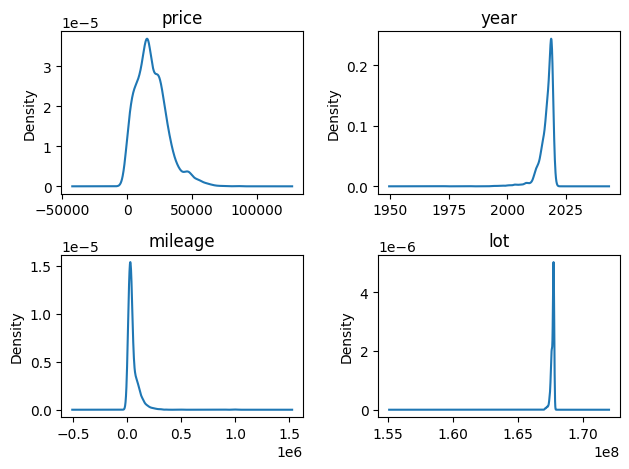

In [92]:
columns = df.columns;
fig, axes = plt.subplots(nrows=2, ncols=2)

# Printing KDE Plot for all the columns present in the Dataset
for i, column in enumerate(columns):
    row = i // 2
    col = i % 2
    
    df[column].plot(kind='density', ax=axes[row][col])
    axes[row][col].set_title(column)

plt.tight_layout()
plt.show()

In [56]:
# We have 3 Skewed Columns, Now, we can apply Function Transformer and Power Transformer to conver this into Natural Distribution

In [57]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer;

In [58]:
# Trying to Remove Skewness from the dataset using Log and Power Transformaton
transformer_function = FunctionTransformer(np.log1p)
transformer_power = PowerTransformer()
df["mileage_transfomed"] = transformer.fit_transform(df["mileage"])
df["year_transfomed"] = transformer_power.fit_transform(df[["year"]])
df["lot_transfomed"] = transformer_power.fit_transform(df[["lot"]])

In [93]:
# Currently, we can see there is impact but not major
df.skew()

price       0.922731
year       -3.559398
mileage     7.079321
lot       -27.781874
dtype: float64

## Applying IQR for Removing Outlier in Skewed Dataset

In [94]:
# Extracting 25% and 75% value for the column
data = df["lot"].quantile([0.25, 0.75]);

In [95]:
# Storing 25% and 75%, and then calcualting IQR value
val_25 = data.iloc[0]
val_75 = data.iloc[1]

iqr = val_75 - val_25

maximum = val_75 + (1.5 * iqr); 
minimum = val_25 - (1.5 * iqr); 

In [97]:
df_outlier_lots = df[(df['lot'] < minimum) | (df['lot'] > maximum)];
df_outlier_lots

,price,year,mileage,lot
0,6300,2008,274117.0,159348797
1,2899,2011,190552.0,166951262
285,0,2000,124969.0,167251902
287,8200,2017,56690.0,167117726
294,725,2017,67279.0,167255037
...,...,...,...,...
623,14000,2017,53424.0,167119104
626,13300,2017,37125.0,167119105
629,15500,2017,37668.0,167119106
631,21500,2017,43761.0,167119107


In [98]:
# Dataframw with lot outlier removed
df_lot_outlier_removed = df.drop(df_outlier_lots.index);
df_lot_outlier_removed

,price,year,mileage,lot
2,5350,2018,39590.0,167655728
3,25000,2014,64146.0,167753855
4,27700,2018,6654.0,167763266
5,5700,2018,45561.0,167655771
6,7300,2010,149050.0,167753872
...,...,...,...,...
2494,7800,2019,23609.0,167722715
2495,9200,2018,34553.0,167762225
2496,9200,2018,31594.0,167762226
2497,9200,2018,32557.0,167762227


<Axes: ylabel='Density'>

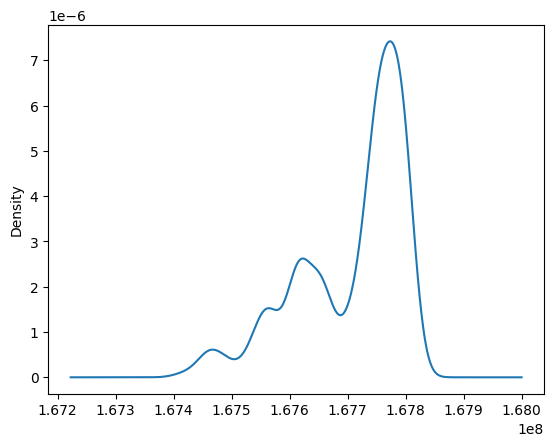

In [104]:
df_lot_outlier_removed["lot"].plot(kind = 'density')

In [102]:
transformer_power = PowerTransformer()
df_lot_outlier_removed["lot_transfomed"] = transformer_power.fit_transform(df_lot_outlier_removed[["lot"]])

In [105]:
df_lot_outlier_removed.skew()

price             0.939786
year             -3.696042
mileage           7.606825
lot              -1.019730
lot_transfomed   -1.007199
dtype: float64